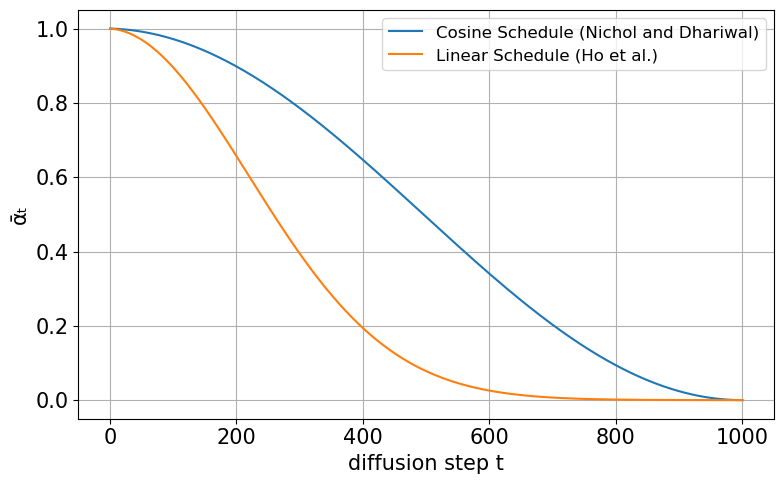

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,          # general font size
    'axes.titlesize': 12,     # title
    'axes.labelsize': 15,     # x and y labels
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 12     # legend
})
# ---------- Noise schedule functions ----------

def exponential_schedule(timesteps, lambda_exp=5.0, s=1e-4):
    steps = timesteps + 1
    x = np.linspace(0, 1, steps)
    alphas2 = np.exp(-lambda_exp * x)
    alphas2 = clip_noise_schedule(alphas2, clip_value=0.001)
    precision = 1 - 2 * s
    alphas2 = precision * alphas2 + s
    return alphas2


def clip_noise_schedule(alphas2, clip_value=0.001):
    alphas2 = np.concatenate([np.ones(1), alphas2], axis=0)
    alphas_step = (alphas2[1:] / alphas2[:-1])
    alphas_step = np.clip(alphas_step, a_min=clip_value, a_max=1.)
    alphas2 = np.cumprod(alphas_step, axis=0)
    return alphas2

def polynomial_schedule(timesteps: int, s=1e-4, power=3.):
    steps = timesteps + 1
    x = np.linspace(0, steps, steps)
    alphas2 = (1 - np.power(x / steps, power))**2
    alphas2 = clip_noise_schedule(alphas2, clip_value=0.001)
    precision = 1 - 2 * s
    alphas2 = precision * alphas2 + s
    return alphas2

def cosine_beta_schedule(timesteps, s=0.008, raise_to_power: float = 1):
    steps = timesteps + 2
    x = np.linspace(0, steps, steps)
    alphas_cumprod = np.cos(((x / steps) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    betas = np.clip(betas, a_min=0, a_max=0.999)
    alphas = 1. - betas
    alphas_cumprod = np.cumprod(alphas, axis=0)
    if raise_to_power != 1:
        alphas_cumprod = np.power(alphas_cumprod, raise_to_power)
    return alphas_cumprod

def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    steps = timesteps + 1
    betas = np.linspace(beta_start, beta_end, steps)
    alphas = 1. - betas
    alphas_cumprod = np.cumprod(alphas, axis=0)
    return alphas_cumprod



# ---------- Plot schedules ----------

timesteps = 1000
t = np.arange(timesteps + 1)

cosine = cosine_beta_schedule(timesteps)
linear = linear_beta_schedule(timesteps)

plt.figure(figsize=(8, 5))
plt.plot(t, cosine, label="Cosine Schedule (Nichol and Dhariwal)")
plt.plot(t, linear, label="Linear Schedule (Ho et al.)")
plt.xlabel("diffusion step t")
plt.ylabel("ᾱₜ")
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


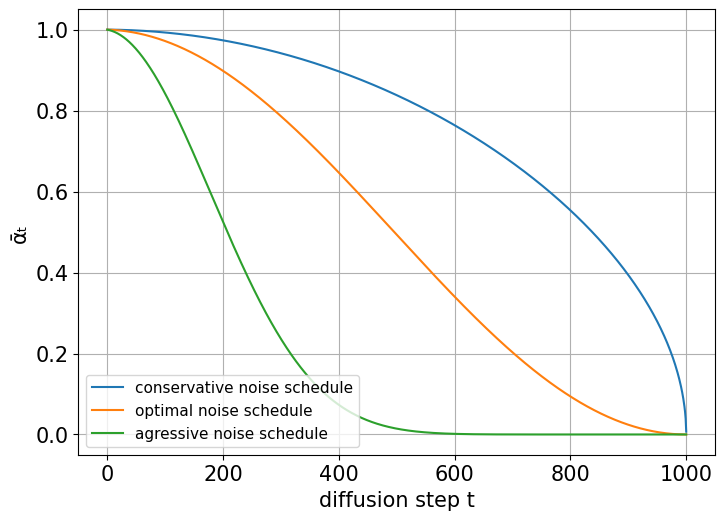

In [16]:
plt.rcParams.update({
    'font.size': 12,          # general font size
    'axes.titlesize': 12,     # title
    'axes.labelsize': 15,     # x and y labels
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 11     # legend
})

def compare_noise_schedules(timesteps=1000):
    schedules = {
        "conservative noise schedule": cosine_beta_schedule(timesteps, raise_to_power=0.25),
        "optimal noise schedule": cosine_beta_schedule(timesteps),
        "agressive noise schedule": cosine_beta_schedule(timesteps, raise_to_power=6)
    }

    t = np.arange(timesteps + 1)
    plt.figure(figsize=(14, 10))

    # α (alpha)
    plt.subplot(2, 2, 1)
    for name, alphas2 in schedules.items():
        plt.plot(t, alphas2, label=name)
    # plt.title('Plot of optimal and sub-optimal noise schedules')
    plt.xlabel("diffusion step t")
    plt.ylabel("ᾱₜ")
    plt.grid(True)
    plt.legend(loc='lower left')

    # # σ (sigma)
    # plt.subplot(2, 2, 2)
    # for name, alphas2 in schedules.items():
    #     plt.plot(t, np.sqrt(1 - alphas2), label=name)
    # plt.title('σ')
    # plt.xlabel('t')
    # plt.ylabel(r'$\sigma_t$')
    # plt.grid(True)
    # plt.legend()
# 
    # # SNR
    # plt.subplot(2, 2, 3)
    # for name, alphas2 in schedules.items():
    #     snr = alphas2 / (1 - alphas2)
    #     plt.plot(t, snr, label=name)
    # plt.title('SNR')
    # plt.xlabel('t')
    # plt.ylabel(r'$\text{SNR}_t$')
    # plt.yscale('log')
    # plt.grid(True)
    # plt.legend()
# 
    # # log SNR
    # plt.subplot(2, 2, 4)
    # for name, alphas2 in schedules.items():
    #     snr = alphas2 / (1 - alphas2)
    #     plt.plot(t, -np.log(snr + 1e-12), label=name)
    # plt.title('-log SNR')
    # plt.xlabel('t')
    # plt.ylabel(r'$\log(\text{SNR}_t)$')
    # plt.grid(True)
    # plt.legend()
# 
    plt.tight_layout()
    plt.show()
    # plt.savefig("noise_schedule_comparison.png", dpi=500, bbox_inches='tight')


# ---- Run comparison ----
compare_noise_schedules(timesteps=1000)

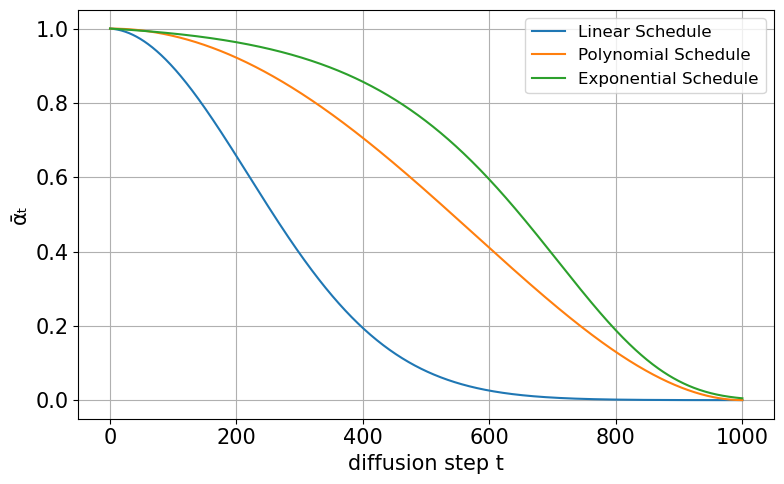

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,          # general font size
    'axes.titlesize': 12,     # title
    'axes.labelsize': 15,     # x and y labels
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 12     # legend
})

# ---------- Noise schedule functions ----------

def clip_noise_schedule(alphas2, clip_value=0.001):
    alphas2 = np.concatenate([np.ones(1), alphas2], axis=0)
    alphas_step = (alphas2[1:] / alphas2[:-1])
    alphas_step = np.clip(alphas_step, a_min=clip_value, a_max=1.)
    alphas2 = np.cumprod(alphas_step, axis=0)
    return alphas2

def polynomial_schedule(timesteps: int, s=1e-4, power=3.):
    steps = timesteps + 1
    x = np.linspace(0, steps, steps)
    alphas2 = (1 - np.power(x / steps, power))**2
    alphas2 = clip_noise_schedule(alphas2, clip_value=0.001)
    precision = 1 - 2 * s
    alphas2 = precision * alphas2 + s
    return alphas2

def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    steps = timesteps + 1
    betas = np.linspace(beta_start, beta_end, steps)
    alphas = 1. - betas
    alphas_cumprod = np.cumprod(alphas, axis=0)
    return alphas_cumprod

# ---------- Exponential schedules ----------

# Variant B: Exponential beta schedule
def exponential_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.03):
    steps = timesteps + 1
    t = np.linspace(0, 1, steps)
    betas = beta_start * (beta_end / beta_start) ** t
    alphas = 1 - betas
    alphas_cumprod = np.cumprod(alphas)
    return alphas_cumprod

# ---------- Plot schedules ----------

timesteps = 1000
t = np.arange(timesteps + 1)

poly2 = polynomial_schedule(timesteps, power=2)
poly3 = polynomial_schedule(timesteps, power=3)
linear = linear_beta_schedule(timesteps)

exp_beta = exponential_beta_schedule(timesteps)

plt.figure(figsize=(8, 5))
plt.plot(t, linear, label="Linear Schedule")
plt.plot(t, poly2, label="Polynomial Schedule")
plt.plot(t, exp_beta, label="Exponential Schedule")

plt.xlabel("diffusion step t")
plt.ylabel("ᾱₜ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
stable_quad = [
    "/content/molecule_stable_000_molecules_eval_quad_9_baseline_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_9_baseline_viz_appendix.jpg",
    "/content/molecule_stable_000_molecules_eval_quad_12_baseline_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_12_baseline_viz_appendix.jpg",
    "/content/molecule_stable_000_molecules_eval_quad_16_baseline_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_16_baseline_viz_appendix.jpg",
    "/content/molecule_stable_000_molecules_eval_quad_20_baseline_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_20_baseline_viz_appendix.jpg",
    "/content/molecule_stable_000_molecules_eval_quad_9_optimal_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_9_optimal_viz_appendix.jpg",
    "/content/molecule_stable_000_molecules_eval_quad_12_optimal_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_12_optimal_viz_appendix.jpg",
    "/content/molecule_stable_000_molecules_eval_quad_16_optimal_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_16_optimal_viz_appendix.jpg",
    "/content/molecule_stable_000_molecules_eval_quad_20_optimal_viz_appendix.jpg",
    "/content/molecule_stable_001_molecules_eval_quad_20_optimal_viz_appendix.jpg",

]